In [ ]:
# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
%matplotlib inline
%config InlineBackend.figure_format='retina'

### Load dataset

In [3]:
# load vis_objects
vis_objects = pd.read_csv('./dataset/vis_objects_set.csv')
vis_objects = vis_objects.iloc[:,1:] # drop row called Unnamed:0 with indices

### Correct Angles and Generate Coordinate DataFrames

In [4]:
# functions
def ra_to_degree(star):
    ls = star.split(' ')
    return 360/24*(float(ls[0]) + float(ls[1])/60 + float(ls[2])/3600)
def dec_to_degree(star):
    ls = star.split(' ')
    if ls[0][0] == '-':
        return -1*(float(ls[0][1:]) + float(ls[1])/60 + float(ls[2])/3600)
    else:
        return float(ls[0]) + float(ls[1])/60 + float(ls[2])/3600

def adjust_coordinates(star_choice):
    new_star_df = vis_objects[['alt_name', 'ra', 'dec', 'distance', 'absmag', 'vmag']].copy()
    new_star_df = new_star_df.loc[(new_star_df != 0).all(axis=1)].dropna(subset=['ra', 'dec', 'distance', 'absmag']) # drop zeroes and na
    new_star_df.reset_index(drop=True, inplace=True)
    sun_dict = {'alt_name': 'Sun', 'ra': '0 0 0.0', 'dec': '0 0 0.0', 'distance': 0, 'absmag': 4.83, 'vmag': 'Nan'}
    new_star_df = pd.concat([new_star_df, pd.DataFrame(sun_dict, index=[0])], ignore_index=True) # add sun to bottom
    new_star_df['ra'] = new_star_df['ra'].apply(ra_to_degree)
    new_star_df['dec'] = new_star_df['dec'].apply(dec_to_degree)
    new_star_df['sun_x'] = new_star_df['distance']*np.cos(new_star_df['dec']*np.pi/180)*np.cos(new_star_df['ra']*np.pi/180)
    new_star_df['sun_y'] = new_star_df['distance']*np.cos(new_star_df['dec']*np.pi/180)*np.sin(new_star_df['ra']*np.pi/180)
    new_star_df['sun_z'] = new_star_df['distance']*np.sin(new_star_df['dec']*np.pi/180)
    new_star_index = new_star_df.loc[new_star_df['alt_name'] == star_choice].index[0]
    new_star_df['star_x'] = new_star_df['sun_x'] - new_star_df.iloc[new_star_index]['sun_x']
    new_star_df['star_y'] = new_star_df['sun_y'] - new_star_df.iloc[new_star_index]['sun_y']
    new_star_df['star_z'] = new_star_df['sun_z'] - new_star_df.iloc[new_star_index]['sun_z']
    new_star_df.drop(index=new_star_index, inplace=True) # drop the star itself
    new_star_df.reset_index(drop=True, inplace=True)
    new_star_df['star_dist'] = np.sqrt(new_star_df['star_x']**2 + new_star_df['star_y']**2 + new_star_df['star_z']**2) 
    new_star_df['star_ra'] = (np.arctan2(new_star_df['star_y'], new_star_df['star_x']) + -1*(np.sign(np.arctan2(new_star_df['star_y'],new_star_df['star_x']))-1)*np.pi) * 180/np.pi 
    new_star_df['star_dec'] = np.arcsin(new_star_df['star_z'] / new_star_df['star_dist']) * 180/np.pi
    new_star_df['star_ap_mag'] = new_star_df['absmag'] + 5 * np.log10(new_star_df['star_dist'] / 10)
    return new_star_df

### Get Constellation Stars

In [6]:
# display brightest stars
b = vis_objects[vis_objects['alt_name'].str.contains('Her') == True].sort_values(by='vmag')[['name','alt_name']].reset_index()
b.head(30)

,index,name,alt_name
0,6173,HR 6148,27BetHer
1,6859,HR 6212,40ZetHer
2,6431,HR 6410,65DelHer
3,7206,HR 6418,67PiHer
4,6623,HR 6623,86MuHer
5,5635,HR 6406,64Alp1Her
6,7369,HR 6220,44EtaHer
7,6724,HR 6703,92XiHer
8,5979,HR 6095,20GamHer
9,7774,HR 6588,85IotHer


In [7]:
# input their indices from one to the next then get names
star_indices = [(8,0),(0,1),(1,6),(6,16),(16,13),(13,17),(17,25),(6,3),(3,26),(26,22),(22,12),(12,9),(3,14),(14,21),(21,2),(21,4),(4,7),(7,10),(14,1)]
starlist = [(b.iloc[pair[0]]['alt_name'],b.iloc[pair[1]]['alt_name']) for pair in star_indices]
print(starlist)

[('20GamHer', '27BetHer'), ('27BetHer', '40ZetHer'), ('40ZetHer', '44EtaHer'), ('44EtaHer', '35SigHer'), ('35SigHer', '22TauHer'), ('22TauHer', '11PhiHer'), ('11PhiHer', '1ChiHer'), ('44EtaHer', '67PiHer'), ('67PiHer', '69Her'), ('69Her', '75RhoHer'), ('75RhoHer', '91TheHer'), ('91TheHer', '85IotHer'), ('67PiHer', '58EpsHer'), ('58EpsHer', '76LamHer'), ('76LamHer', '65DelHer'), ('76LamHer', '86MuHer'), ('86MuHer', '92XiHer'), ('92XiHer', '103OmiHer'), ('58EpsHer', '40ZetHer')]


### Constellation Lines

In [8]:
# constellation line star pairs
UMa_pairs = [('69DelUMa', '50AlpUMa'), ('50AlpUMa', '48BetUMa'), ('48BetUMa', '64GamUMa'), ('64GamUMa', '69DelUMa'), ('69DelUMa', '77EpsUMa'), ('77EpsUMa', '79ZetUMa'), ('79ZetUMa', '85EtaUMa')]
Cas_pairs = [('11BetCas', '18AlpCas'), ('18AlpCas', '24EtaCas'), ('24EtaCas', '27GamCas'), ('27GamCas', '37DelCas'), ('37DelCas', '45EpsCas')]
UMi_pairs = [('1AlpUMi', '23DelUMi'), ('23DelUMi', '22EpsUMi'), ('22EpsUMi', '16ZetUMi'), ('16ZetUMi', '21EtaUMi') ,('21EtaUMi', '13GamUMi'), ('13GamUMi', '7BetUMi'), ('7BetUMi', '16ZetUMi')]
Cep_pairs = [('35GamCep', '32IotCep'), ('32IotCep', '21ZetCep'), ('21ZetCep', '5AlpCep'), ('5AlpCep', '8BetCep'), ('8BetCep', '32IotCep'), ('8BetCep', '35GamCep')]
CrB_pairs = [('14IotCrB', '13EpsCrB'), ('13EpsCrB', '10DelCrB'), ('10DelCrB', '8GamCrB'), ('8GamCrB', '5AlpCrB'), ('5AlpCrB', '3BetCrB'), ('3BetCrB', '4TheCrB')]
Boo_pairs = [('5UpsBoo', '8EtaBoo'), ('8EtaBoo', '16AlpBoo'), ('30ZetBoo', '16AlpBoo'), ('16AlpBoo', '36EpsBoo'), ('36EpsBoo', '49DelBoo'), ('49DelBoo', '42BetBoo'), ('42BetBoo', '27GamBoo'), ('27GamBoo', '25RhoBoo'), ('25RhoBoo', '16AlpBoo')]
Leo_pairs = [('17EpsLeo', '24MuLeo'), ('24MuLeo', '36ZetLeo'), ('36ZetLeo', '41Gam1Leo'), ('41Gam1Leo', '68DelLeo'), ('68DelLeo', '94BetLeo'), ('94BetLeo', '70TheLeo'), ('70TheLeo', '68DelLeo'), ('70TheLeo', '32AlpLeo'), ('32AlpLeo', '30EtaLeo'), ('30EtaLeo', '41Gam1Leo')]
Gem_pairs = [('31XiGem', '54LamGem'), ('54LamGem', '55DelGem'), ('55DelGem', '43ZetGem'), ('43ZetGem', '24GamGem'), ('55DelGem', '69UpsGem'), ('69UpsGem', '78BetGem'), ('77KapGem', '69UpsGem'), ('69UpsGem', '60IotGem'), ('60IotGem', '46TauGem'), ('46TauGem', '34TheGem'), ('66AlpGem', '46TauGem'), ('46TauGem', '27EpsGem'), ('27EpsGem', '18NuGem'), ('27EpsGem', '13MuGem'), ('13MuGem', '7EtaGem'), ('7EtaGem', '1Gem')]
Aur_pairs = [('13AlpAur', '8ZetAur'), ('8ZetAur', '3IotAur'), ('3IotAur', '112BetTau'), ('112BetTau', '37TheAur'), ('37TheAur', '34BetAur'), ('34BetAur', '13AlpAur')]
Tau_pairs = [('112BetTau', '94TauTau'), ('94TauTau', '74EpsTau'), ('74EpsTau', '68Del3Tau'), ('68Del3Tau', '61Del1Tau'), ('61Del1Tau', '54GamTau'), ('54GamTau', '35LamTau'), ('35LamTau', '1OmiTau'), ('54GamTau', '78The2Tau'), ('78The2Tau', '87AlpTau'), ('87AlpTau', '123ZetTau')]
Cyg_pairs = [('78Mu1Cyg', '64ZetCyg'), ('64ZetCyg', '53EpsCyg'), ('53EpsCyg', '37GamCyg'), ('37GamCyg', '18DelCyg'), ('18DelCyg', '10Iot2Cyg'), ('10Iot2Cyg', '1KapCyg'), ('50AlpCyg', '37GamCyg'), ('37GamCyg', '21EtaCyg'), ('21EtaCyg', '6Bet1Cyg')]
Ori_pairs = [('54Chi1Ori', '62Chi2Ori'), ('62Chi2Ori', '69Ori'), ('69Ori', '70XiOri'), ('70XiOri', '67NuOri'), ('67NuOri', '54Chi1Ori'), ('67NuOri', '61MuOri'), ('70XiOri', '61MuOri'), ('61MuOri', '58AlpOri'), ('58AlpOri', '39LamOri'), ('39LamOri', '24GamOri'), ('24GamOri', '1Pi3Ori'), ('1Pi3Ori', '2Pi2Ori'), ('2Pi2Ori', '7Pi1Ori'), ('1Pi3Ori', '3Pi4Ori'), ('3Pi4Ori', '5Ori'), ('5Ori', '10Pi6Ori'), ('24GamOri', '34DelOri'), ('34DelOri', '46EpsOri'), ('46EpsOri', '50ZetOri'), ('50ZetOri', '58AlpOri'), ('50ZetOri', '53KapOri'), ('53KapOri', '19BetOri'), ('19BetOri', '34DelOri')]
Aql_pairs = [('16LamAql', '30DelAql'), ('30DelAql', '17ZetAql'), ('17ZetAql', '13EpsAql'), ('30DelAql', '55EtaAql'), ('55EtaAql', '65TheAql'), ('30DelAql', '53AlpAql'), ('53AlpAql', '50GamAql'), ('53AlpAql', '60BetAql')]
Per_pairs = [('38OmiPer', '44ZetPer'), ('44ZetPer', '46XiPer'), ('46XiPer', '45EpsPer'), ('45EpsPer', '39DelPer'), ('39DelPer', '33AlpPer'), ('33AlpPer', '23GamPer'), ('23GamPer', '15EtaPer'), ('33AlpPer', '26BetPer'), ('26BetPer', '25RhoPer'), ('25RhoPer', '16Per')]
Her_pairs = [('20GamHer', '27BetHer'), ('27BetHer', '40ZetHer'), ('40ZetHer', '44EtaHer'), ('44EtaHer', '35SigHer'), ('35SigHer', '22TauHer'), ('22TauHer', '11PhiHer'), ('11PhiHer', '1ChiHer'), ('44EtaHer', '67PiHer'), ('67PiHer', '69Her'), ('69Her', '75RhoHer'), ('75RhoHer', '91TheHer'), ('91TheHer', '85IotHer'), ('67PiHer', '58EpsHer'), ('58EpsHer', '76LamHer'), ('76LamHer', '65DelHer'), ('76LamHer', '86MuHer'), ('86MuHer', '92XiHer'), ('92XiHer', '103OmiHer'), ('58EpsHer', '40ZetHer')]


constellations = [UMa_pairs, Cas_pairs, UMi_pairs, Cep_pairs, CrB_pairs, Boo_pairs, Leo_pairs, Gem_pairs, 
                  Aur_pairs, Tau_pairs, Cyg_pairs, Ori_pairs, Aql_pairs, Per_pairs, Her_pairs]

### Input Stars and Conditions

In [9]:
close_stars = ['Alp1Cen', 'Alp2Cen', '9AlpCMa', '18EpsEri', '61Cyg', '10AlpCMi', 'EpsInd', '24EtaCas', '70Oph', '61SigDra', '53AlpAql']
viewing_stars = ['Sun', '53AlpAql']
viewing_constellations = True
bad_seeing = True
if bad_seeing:
    # bad seeing
    mag_map_size = {-2:3.0, -1.0:2.6, 0:2.3, 1:2.1, 2:1.2, 3:1.1, 4:0.9, 5:0.5, 6:0.4, 7:0.1, 8:0.01}
    mag_map_alpha = {-2:1, -1:1, 0:0.9, 1:0.5, 2:0.5, 3:0.4, 4:0.2, 5:0.1, 6:0.1, 7:0.1}
else:
    # good seeing
    mag_map_size = {-2:2.2, -1.0:1.9, 0:1.7, 1:1.5, 2:1.3, 3:1.1, 4:0.9, 5:0.5, 6:0.4, 7:0.1, 8:0.01}
    mag_map_alpha = {-3:1, -2:1, -1:1, 0:0.9, 1:0.8, 2:0.85, 3:0.5, 4:0.2, 5:0.2, 6:0.1, 7:0.1}


### Northern Sky

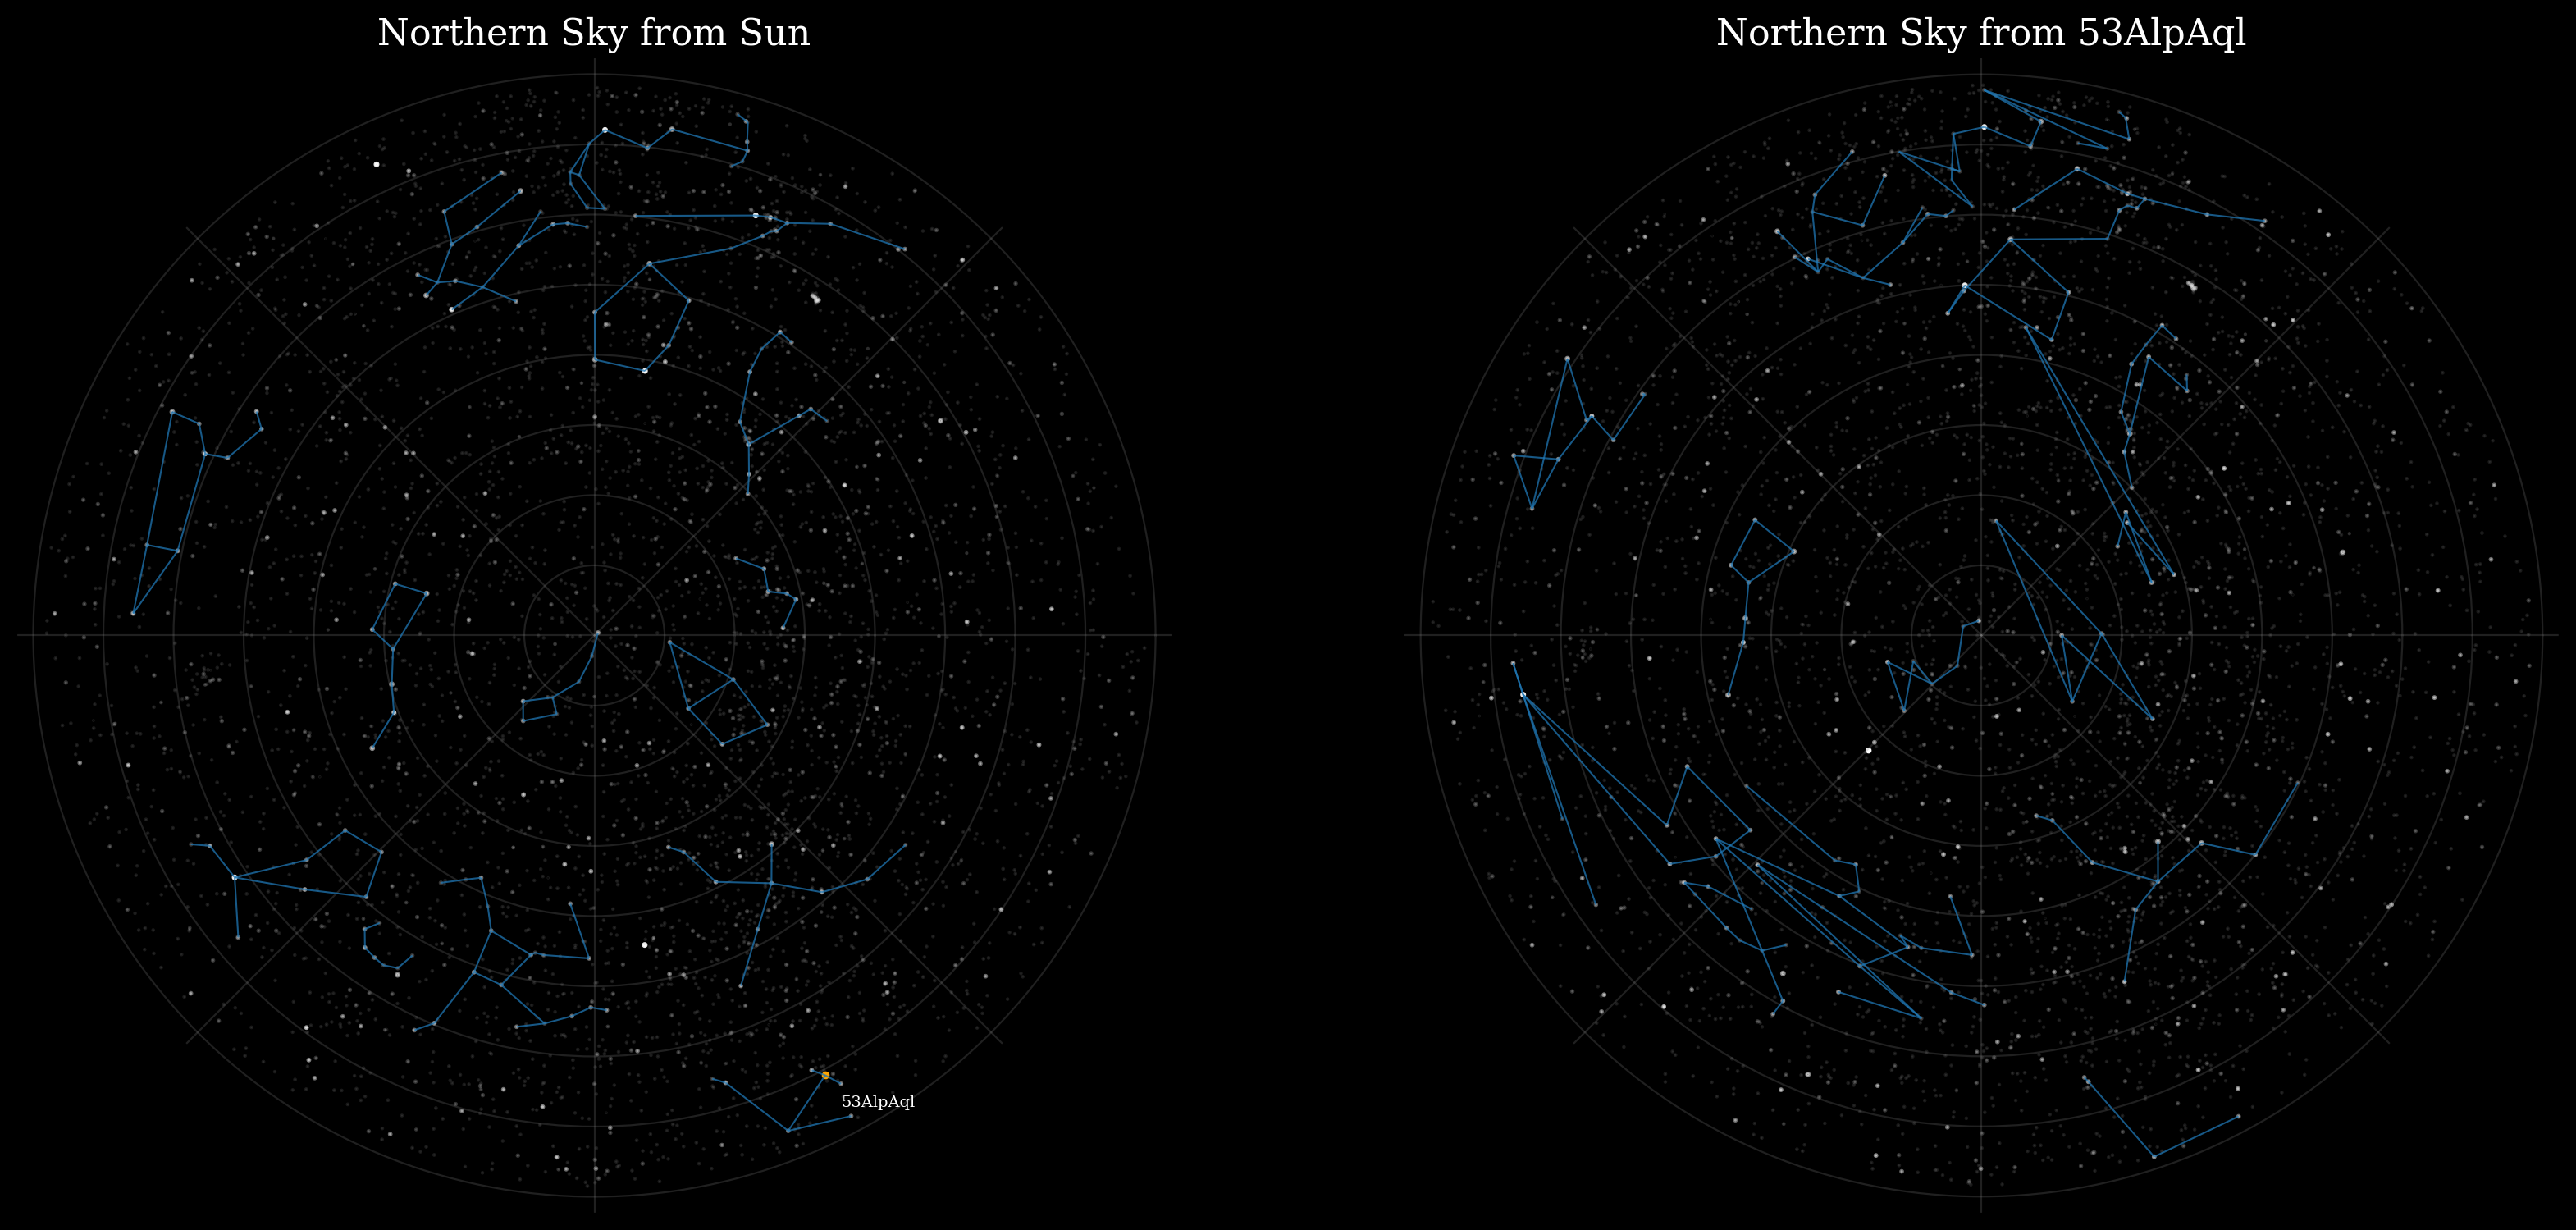

In [10]:
fig, ax = plt.subplots(1, len(viewing_stars), subplot_kw={'projection': 'polar'}, figsize=(20,20)) 
fig.set_facecolor(color='black')
font = {'family':'serif', 'color':'darkred', 'weight':'normal'}
for (i, star_choice) in enumerate(viewing_stars):
    new_star_df = adjust_coordinates(star_choice)

    # drop any companion star
    new_star_df = new_star_df.loc[new_star_df['star_ap_mag'] > -3]
    # northern hemisphere
    northern_df = new_star_df.loc[new_star_df['star_dec'] > 0]
    northern_df.reset_index(drop=True, inplace=True)
    theta, r = np.array(northern_df['star_ra']*np.pi/180), np.array((90 - northern_df['star_dec'])*np.pi/180)
    mag_sections_alpha = np.trunc(northern_df['star_ap_mag']).map(mag_map_alpha)
    mag_sections_size = np.trunc(northern_df['star_ap_mag']).map(mag_map_size)
    mag_sections_alpha = mag_sections_alpha.fillna(0.1)
    mag_sections_size = mag_sections_size.fillna(0.1)
    ax[i].scatter(theta, r, c='white', s=mag_sections_size, alpha=mag_sections_alpha)
    if star_choice == 'Sun' and i == 0:
        for starname in viewing_stars[1:]: # other stars
            if not northern_df.loc[northern_df['alt_name'] == starname].empty:
                other_star_index = northern_df.loc[northern_df['alt_name'] == starname].index
                ax[i].scatter(theta[other_star_index], r[other_star_index], c='orange', s=6, alpha=1)
                ax[i].text(theta[other_star_index[0]], r[other_star_index[0]]+0.1, starname, c='white', fontsize=7, fontdict=font) # [0] in case it has the same alt_name
            else:
                pass

    def get_line(pair):
        try: # in case the dec is below 0 so it can't find it in northern_df
            ind1 = northern_df.loc[northern_df['alt_name'] == pair[0]].index[0]
            ind2 = northern_df.loc[northern_df['alt_name'] == pair[1]].index[0]
            theta1, theta2 = theta[ind1], theta[ind2]
            r1, r2 = r[ind1], r[ind2]
            l = [(theta1, r1), (theta2, r2)]
            return l
        except:
            return [(0,0),(0,0)]
    if viewing_constellations:
        for constpairs in constellations:
            lines = [get_line(pair) for pair in constpairs]
            ax[i].add_collection(LineCollection(lines, color='C0', lw=0.75, alpha=0.75))
    ax[i].set_facecolor(color='black')
    ax[i].grid(color='grey',alpha=0.25)
    ax[i].set_title('Northern Sky from ' + star_choice, fontdict=font, fontsize=16, color='white')
    ax[i].set_xticklabels([])
    ax[i].set_yticklabels([]);

### Southern Sky

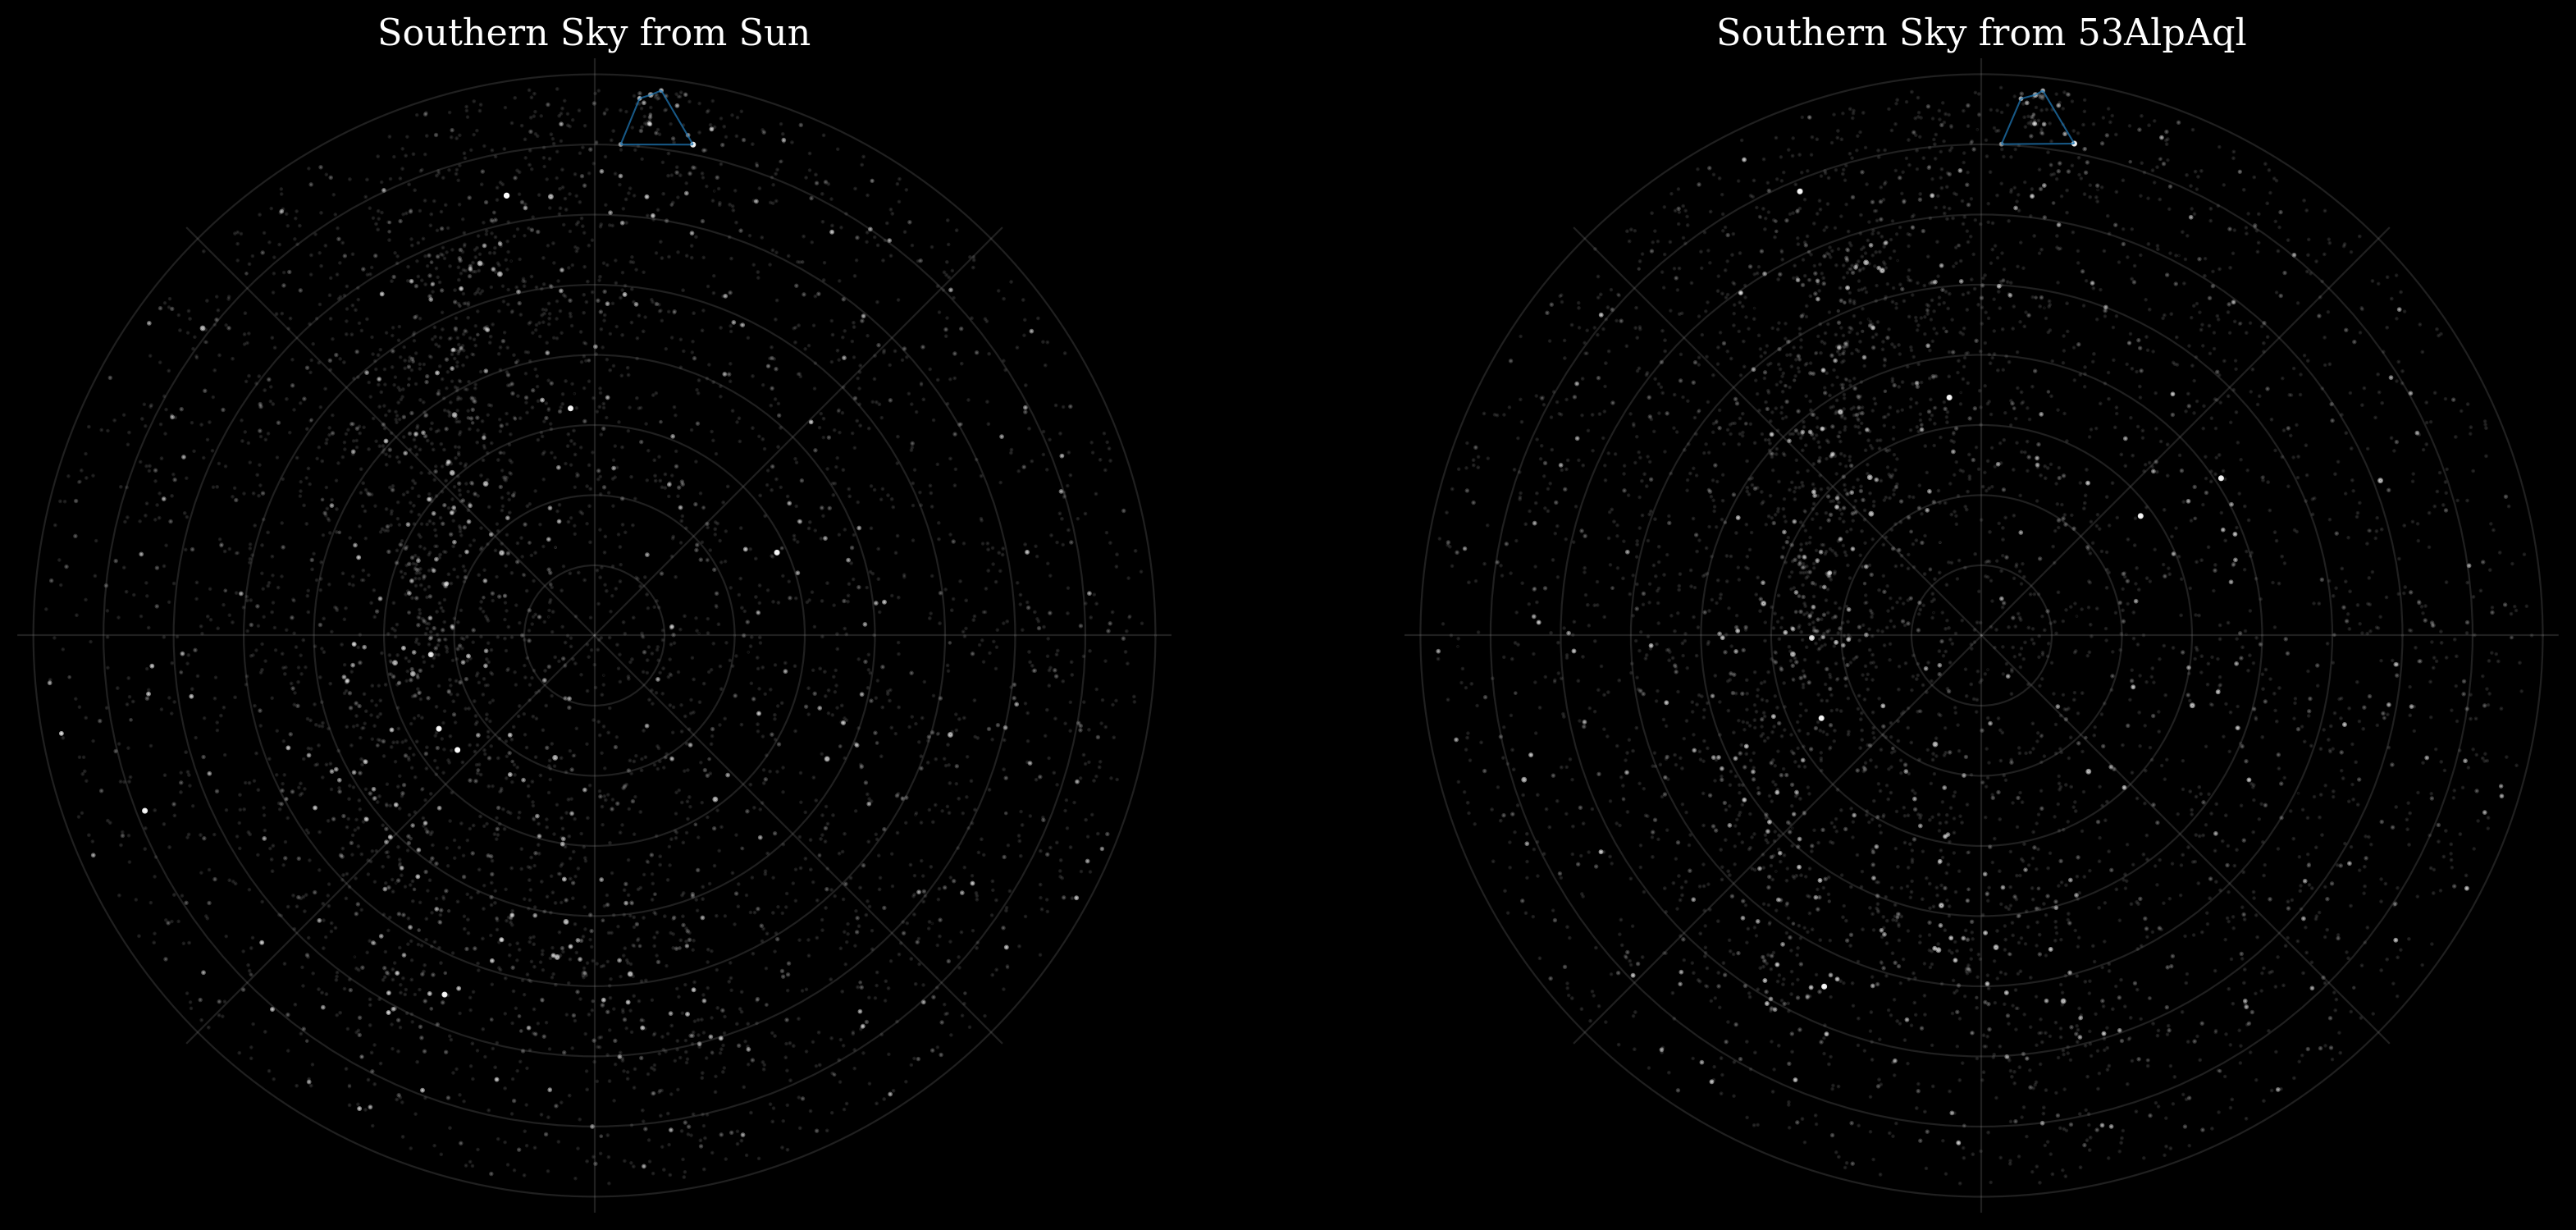

In [38]:
fig, ax = plt.subplots(1, len(viewing_stars), subplot_kw={'projection': 'polar'}, figsize=(20,20)) 
fig.set_facecolor(color='black')
font = {'family':'serif', 'color':'darkred', 'weight':'normal'}
for (i, star_choice) in enumerate(viewing_stars):
    new_star_df = adjust_coordinates(star_choice)

    # drop any companion star
    new_star_df = new_star_df.loc[new_star_df['star_ap_mag'] > -3]
    # northern hemisphere
    southern_df = new_star_df.loc[new_star_df['star_dec'] < 0]
    southern_df.reset_index(drop=True, inplace=True)
    theta, r = np.array(southern_df['star_ra']*np.pi/180), np.array((90 + southern_df['star_dec'])*np.pi/180)
    mag_sections_alpha = np.trunc(southern_df['star_ap_mag']).map(mag_map_alpha)
    mag_sections_size = np.trunc(southern_df['star_ap_mag']).map(mag_map_size)
    mag_sections_alpha = mag_sections_alpha.fillna(0.1)
    mag_sections_size = mag_sections_size.fillna(0.1)
    ax[i].scatter(theta, r, c='white', s=mag_sections_size, alpha=mag_sections_alpha)
    if star_choice == 'Sun' and i == 0:
        for starname in viewing_stars[1:]: # other stars
            if not southern_df.loc[southern_df['alt_name'] == starname].empty:
                other_star_index = southern_df.loc[southern_df['alt_name'] == starname].index
                ax[i].scatter(theta[other_star_index], r[other_star_index], c='orange', s=6, alpha=1)
                ax[i].text(theta[other_star_index[0]], r[other_star_index[0]]+0.1, starname, c='white', fontsize=7, fontdict=font) # [0] in case there are 2 with same alt_name
            else:
                pass
    def get_line(pair):
        try: # in case the dec is below 0 so it can't find it in northern_df
            ind1 = southern_df.loc[southern_df['alt_name'] == pair[0]].index[0]
            ind2 = southern_df.loc[southern_df['alt_name'] == pair[1]].index[0]
            theta1, theta2 = theta[ind1], theta[ind2]
            r1, r2 = r[ind1], r[ind2]
            l = [(theta1, r1), (theta2, r2)]
            return l
        except:
            return [(0,0),(0,0)]
    if viewing_constellations:
        for constpairs in constellations:
            lines = [get_line(pair) for pair in constpairs]
            ax[i].add_collection(LineCollection(lines, color='C0', lw=0.75, alpha=0.75))
    ax[i].set_facecolor(color='black')
    ax[i].grid(color='grey',alpha=0.25)
    ax[i].set_title('Southern Sky from ' + star_choice, fontdict=font, fontsize=16, color='white')
    ax[i].set_xticklabels([])
    ax[i].set_yticklabels([]);